In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [44]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [5]:
df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Housing.csv")
df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


In [6]:
df.shape

(545, 13)

In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

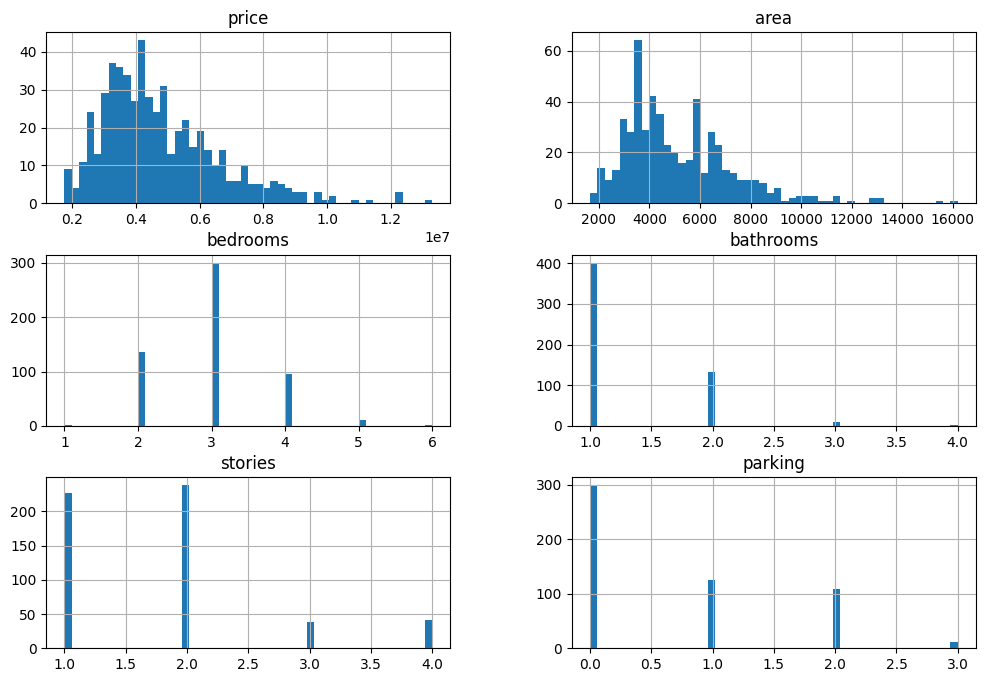

In [10]:
df.hist(figsize = (12,8), bins = 50)

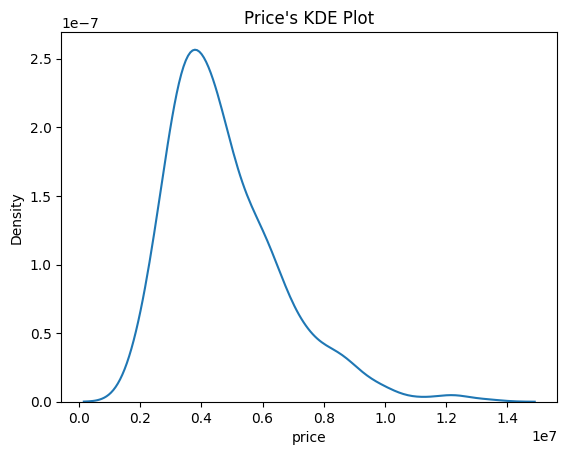

In [12]:
sns.kdeplot(data = df, x = 'price')
plt.title("Price's KDE Plot")
plt.show()

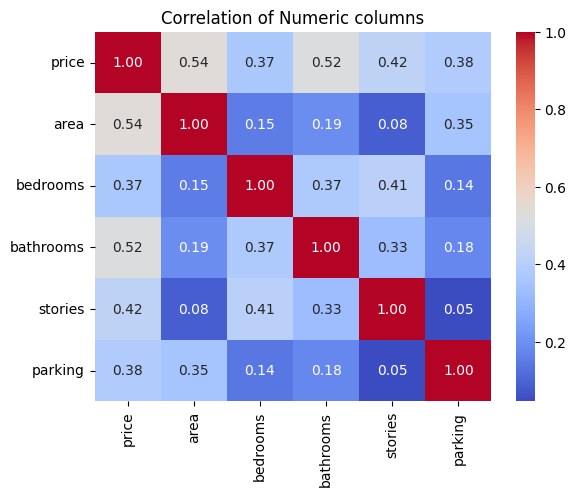

In [15]:
numeric_col = df.select_dtypes( include = np.number ).columns

sns.heatmap(
    df[numeric_col].corr(),
    annot = True,
    cmap = 'coolwarm',
    fmt = ".2f"
)

plt.title('Correlation of Numeric columns')
plt.show()

In [16]:
df.sample(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
203,4900000,5400,4,1,2,yes,no,no,no,no,0,no,semi-furnished
423,3360000,3750,3,1,1,yes,no,no,no,no,0,no,unfurnished


<Axes: xlabel='bedrooms', ylabel='count'>

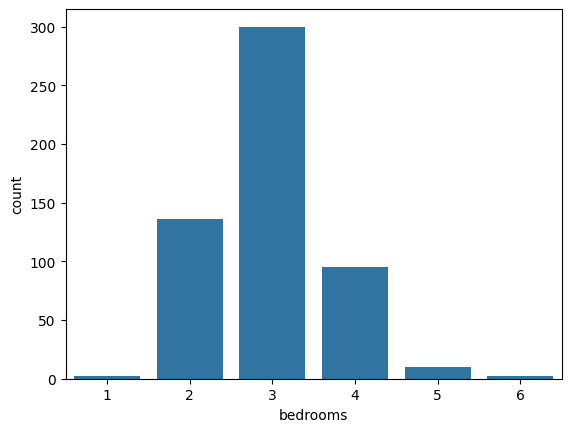

In [17]:
sns.countplot(data = df, x = 'bedrooms')

<Axes: xlabel='bedrooms', ylabel='price'>

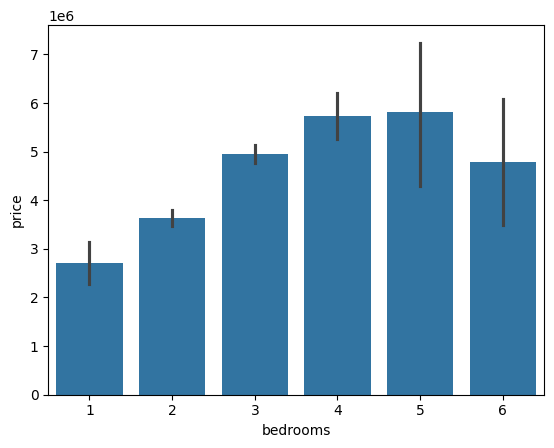

In [18]:
sns.barplot(data = df, x = 'bedrooms', y = 'price')


In [20]:
avg_price = df.groupby('bedrooms')['price'].mean()
avg_price

bedrooms
1    2.712500e+06
2    3.632022e+06
3    4.954598e+06
4    5.729758e+06
5    5.819800e+06
6    4.791500e+06
Name: price, dtype: float64

In [19]:
df['bedrooms'].value_counts()

bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64

In [21]:
df.sample(1)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
32,8295000,4880,4,2,2,yes,no,no,no,yes,1,yes,furnished


<Axes: xlabel='bathrooms', ylabel='price'>

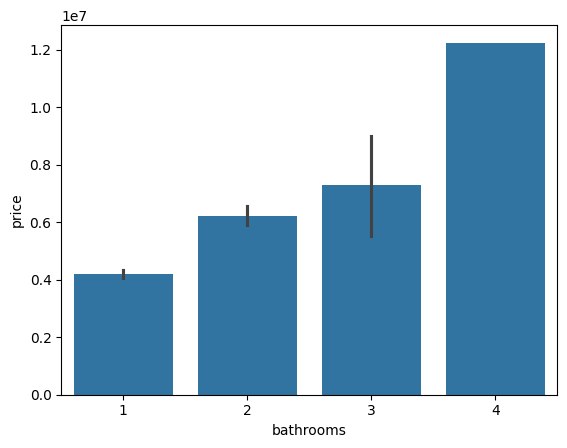

In [22]:
sns.barplot(data = df, x = 'bathrooms', y = 'price')

In [23]:
avg_price = df.groupby('bathrooms')['price'].mean()
avg_price

bathrooms
1    4.206913e+06
2    6.209206e+06
3    7.282100e+06
4    1.225000e+07
Name: price, dtype: float64

In [24]:
df['bathrooms'].value_counts()

bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64

In [25]:
df.sample(1)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
228,4690000,3630,3,1,2,yes,no,no,no,no,2,no,semi-furnished


In [26]:
df['stories'].value_counts()

stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64

<Axes: xlabel='stories', ylabel='price'>

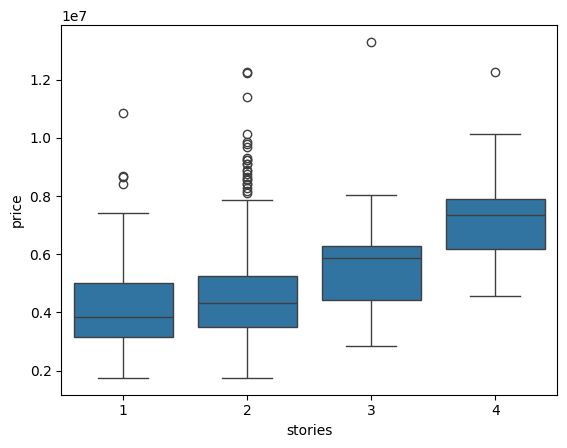

In [28]:
sns.boxplot(data = df, x = 'stories', y = 'price')

In [29]:
df['stories'].value_counts()

stories
2    238
1    227
4     41
3     39
Name: count, dtype: int64

In [30]:
categorical_columns = df.select_dtypes( include = 'object').columns
categorical_columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [31]:
df[categorical_columns]

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [35]:
df[categorical_columns].value_counts()

mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea  furnishingstatus
yes       no         no        no               no               no        unfurnished         63
                                                                           semi-furnished      58
                                                                           furnished           30
                                                yes              no        semi-furnished      25
                     yes       no               no               no        semi-furnished      21
                                                                                               ..
no        no         yes       no               no               yes       unfurnished          1
yes       no         yes       yes              no               no        semi-furnished       1
no        yes        yes       no               yes              no        unfurnished          1
yes       yes        no   

<Axes: xlabel='mainroad', ylabel='price'>

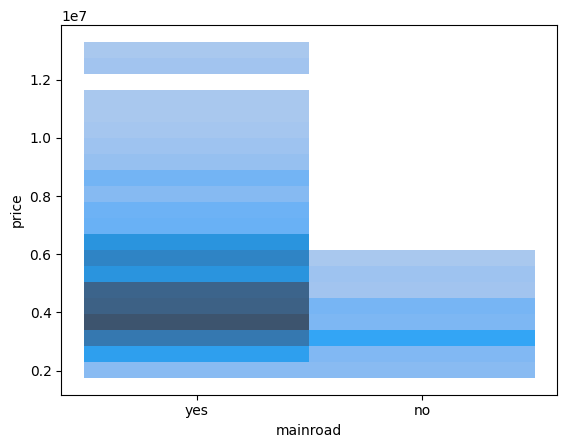

In [39]:
sns.histplot(data = df, x = 'mainroad', y = 'price')

<Axes: xlabel='mainroad', ylabel='price'>

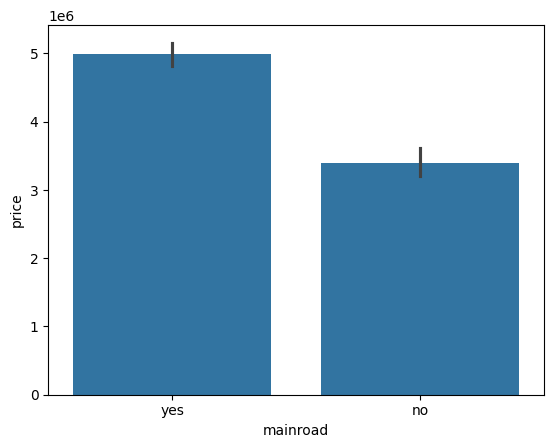

In [40]:
sns.barplot(data = df, x = 'mainroad', y = 'price')

<Axes: xlabel='mainroad', ylabel='price'>

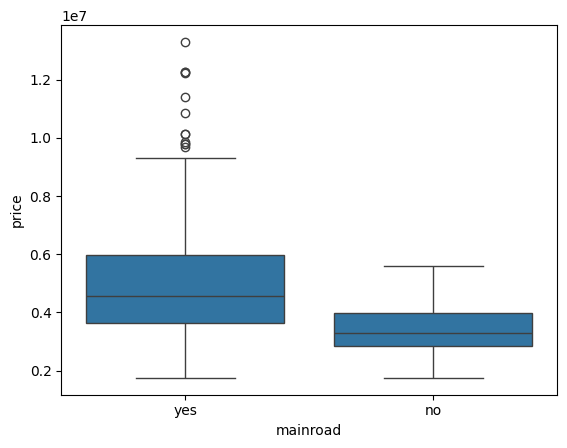

In [41]:
sns.boxplot(data = df, x = 'mainroad', y = 'price')

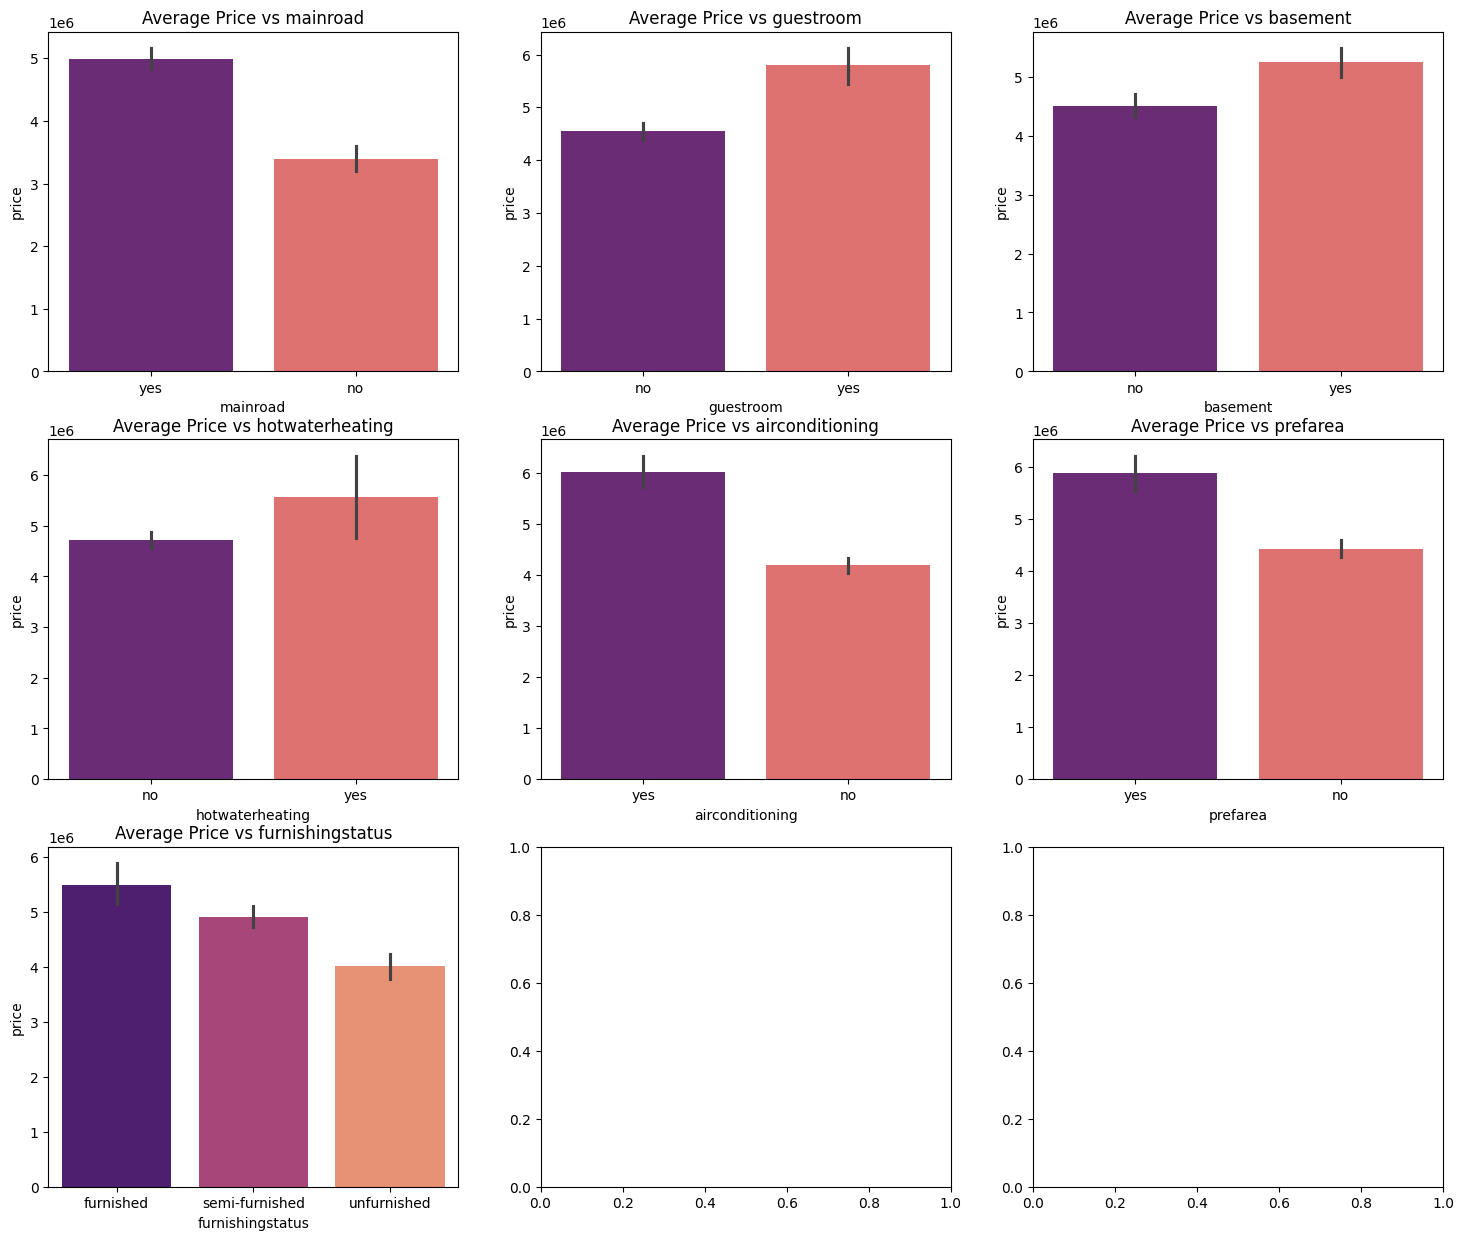

In [42]:


n_cols = 3
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize = (18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    sns.barplot(data = df, x = col, y = 'price', ax = axes[i], palette = 'magma')
    axes[i].set_title(f"Average Price vs {col}")

plt.show()

In [45]:
X = df.drop(columns = 'price')
y = df['price']

In [46]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [47]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [62]:
cat_transform = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder( handle_unknown = 'ignore', sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ('cat', cat_transform, categorical_columns)
    ]
)

preprocess

,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [63]:
preprocess.set_output(transform="pandas")

X_train_transformed = preprocess.fit_transform(X_train)
X_test_transformed = preprocess.transform(X_test)

X_train_transformed.head()

,cat__mainroad_no,cat__mainroad_yes,cat__guestroom_no,cat__guestroom_yes,cat__basement_no,cat__basement_yes,cat__hotwaterheating_no,cat__hotwaterheating_yes,cat__airconditioning_no,cat__airconditioning_yes,cat__prefarea_no,cat__prefarea_yes,cat__furnishingstatus_furnished,cat__furnishingstatus_semi-furnished,cat__furnishingstatus_unfurnished
283,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
373,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
120,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
48,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
8,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0


In [64]:
X_test_transformed

,cat__mainroad_no,cat__mainroad_yes,cat__guestroom_no,cat__guestroom_yes,cat__basement_no,cat__basement_yes,cat__hotwaterheating_no,cat__hotwaterheating_yes,cat__airconditioning_no,cat__airconditioning_yes,cat__prefarea_no,cat__prefarea_yes,cat__furnishingstatus_furnished,cat__furnishingstatus_semi-furnished,cat__furnishingstatus_unfurnished
437,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
308,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
111,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
37,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
508,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
258,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
443,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
470,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [65]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocess),
    ('model', LinearRegression())
])


ETA = 0.001
MAX_ITER = 3000
ALPHA = 0.0001

sgd_pipeline = Pipeline(steps=[
    ('preprocessor', preprocess),
    ('model', SGDRegressor(
        loss="squared_error",
        penalty='l2',
        alpha=ALPHA,
        learning_rate='constant',
        eta0=ETA,
        max_iter=MAX_ITER,
        random_state=42
    ))
])

In [66]:
lr_pipeline.fit(X_train, y_train)
sgd_pipeline.fit(X_train, y_train)

def evaluate_pipeline(pipeline, name):
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    print(f"\n{name} (Using Pipeline) Results")
    print("-" * 40)
    print("Train R2 :", round(r2_score(y_train, train_pred), 4))
    print("Test R2  :", round(r2_score(y_test, test_pred), 4))
    print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, test_pred)), 4))
    print("MAE      :", round(mean_absolute_error(y_test, test_pred), 4))


evaluate_pipeline(lr_pipeline, "Linear Regression")
evaluate_pipeline(sgd_pipeline, "SGD Regressor")


Linear Regression (Using Pipeline) Results
----------------------------------------
Train R2 : 0.3886
Test R2  : 0.471
RMSE     : 1326339.9278
MAE      : 962615.4578

SGD Regressor (Using Pipeline) Results
----------------------------------------
Train R2 : 0.3835
Test R2  : 0.4598
RMSE     : 1340247.4503
MAE      : 966142.162
